# Laboratorio 5 — Regresión logística desde cero

El modelo de clasificación probabilística no tiene solución cerrada: hay que ajustarlo
iterando. Este laboratorio construye las cuatro piezas y las verifica contra
`scikit-learn`:

1. La **función logística**, numéricamente estable.
2. La **entropía cruzada**, contrastada con `log_loss`.
3. Su **gradiente**, verificado contra diferencias finitas.
4. El **ajuste completo**, que reutiliza el descenso por gradiente ya escrito.

Y después lo que justifica todo lo anterior: **interpretar los coeficientes**. Como el
conjunto de datos es sintético y se conoce el modelo que lo generó, cada estimación se
puede contrastar contra su valor verdadero.

Hay **siete ejercicios**. Las celdas que contienen `raise NotImplementedError()` deben
completarse; el resto es andamiaje y se ejecuta sin modificar.

## 0. Preparación

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (8, 3.6), "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(precision=4, suppress=True)

AZUL, TURQUESA, NARANJA = "#19326E", "#50ACB0", "#CD742A"
VIOLETA, OLIVA, AZUL_CLARO = "#A3477F", "#89A943", "#4294CC"

### Los datos

4000 solicitudes de crédito de consumo con su desenlace observado. **La clase positiva es
el incumplimiento**: `incumplio = 1` significa que el crédito no se pagó.

In [3]:
#@title Carga del conjunto de datos (ejecutar sin modificar) { display-mode: "form" }

datos = pd.read_csv("https://raw.githubusercontent.com/gustavovazquez/datasets/refs/heads/main/riesgo_credito.csv")
print(f"Cargado:   {datos.shape[0]} filas x {datos.shape[1]} columnas")
print(f"Tasa de incumplimiento: {datos['incumplio'].mean():.1%}")
datos.head(3)

Cargado:   4000 filas x 12 columnas
Tasa de incumplimiento: 21.8%


,id_solicitud,edad_anios,antiguedad_laboral_anios,ingreso_mensual_usd,monto_solicitado_usd,plazo_meses,cuota_mensual_usd,cuota_ingreso,historial_crediticio,consultas_buro_12m,tiene_garantia,incumplio
0,SC-02061,36,13.4,1690.0,5960.0,24,344.08,0.2036,al dia,0,0,0
1,SC-00934,36,5.0,900.0,8640.0,36,441.03,0.4900,sin historial,2,0,1
2,SC-00379,52,2.0,540.0,800.0,36,43.12,0.0799,con atrasos,2,0,0


### Las variables

El historial crediticio es categórico con tres niveles. Se lo codifica dejando **«al día»
como categoría de referencia**: los dos coeficientes resultantes se leen siempre respecto
de ella. El monto entra en logaritmo y la edad, centrada, porque así fueron generados.

In [4]:
#@title Construcción de la matriz de diseño (ejecutar sin modificar) { display-mode: "form" }
tabla = datos.copy()
tabla["hist_atrasos"] = (tabla["historial_crediticio"] == "con atrasos").astype(int)
tabla["hist_sin"] = (tabla["historial_crediticio"] == "sin historial").astype(int)
tabla["log_monto"] = np.log(tabla["monto_solicitado_usd"]) - np.log(10_000)
tabla["edad_c"] = tabla["edad_anios"] - 38

ATRIBUTOS = ["cuota_ingreso", "hist_atrasos", "hist_sin", "consultas_buro_12m",
             "antiguedad_laboral_anios", "tiene_garantia", "edad_c", "log_monto"]

X = np.column_stack([np.ones(len(tabla)), tabla[ATRIBUTOS].to_numpy(dtype=float)])
y = tabla["incumplio"].to_numpy(dtype=float)
n = len(y)
NOMBRES = ["intercepto"] + ATRIBUTOS

print(f"X: {X.shape}   y: {y.shape}   coeficientes a estimar: {X.shape[1]}")
print(f"Positivos: {int(y.sum())} de {n}  ({y.mean():.1%})")

X: (4000, 9)   y: (4000,)   coeficientes a estimar: 9
Positivos: 873 de 4000  (21.8%)


---

# 1. La función logística

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

### Ejercicio 1

Implementarla. **Cuidado con el desborde:** para $z$ muy negativo, `np.exp(-z)` desborda y
devuelve `inf`. Recortar el argumento con `np.clip` a un rango seguro resuelve el problema
sin alterar el resultado, porque $\sigma(-500)$ ya es cero a precisión de máquina.

In [6]:
def sigmoide(z: np.ndarray) -> np.ndarray:
    """Función logística, aplicada componente a componente.

    Parámetros
    ----------
    z : arreglo de estimaciones lineales

    Devuelve
    --------
    arreglo con los valores en (0, 1)
    """
    # TODO: implementar
    z = np.clip(z, -500, 500)      # evita que exp() explote
    return 1 / (1 + np.exp(-z))    # la fórmula matemática tal cual


sigma(0)      = 0.5
sigma(2)      = 0.8808
sigma(-2)     = 0.1192
sigma(-1000)  = 7.124576406741285e-218  (sin desborde)

Propiedades verificadas: vale 0,5 en el origen, es creciente y es simétrica.


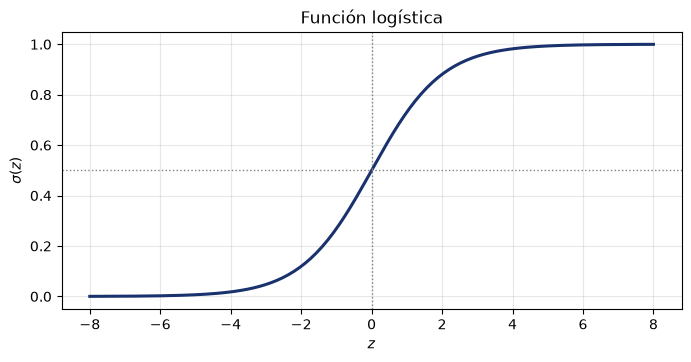

In [7]:
# VERIFICACIÓN — las propiedades de la sigmoide
print("sigma(0)      =", sigmoide(np.array([0.0]))[0])
print("sigma(2)      =", sigmoide(np.array([2.0]))[0].round(4))
print("sigma(-2)     =", sigmoide(np.array([-2.0]))[0].round(4))
print("sigma(-1000)  =", sigmoide(np.array([-1000.0]))[0], " (sin desborde)")

z = np.linspace(-8, 8, 200)
assert np.isclose(sigmoide(np.array([0.0]))[0], 0.5)
assert np.all(np.diff(sigmoide(z)) > 0), "debe ser creciente"
assert np.allclose(sigmoide(-z), 1 - sigmoide(z)), "debe cumplir sigma(-z) = 1 - sigma(z)"
print("\nPropiedades verificadas: vale 0,5 en el origen, es creciente y es simétrica.")

fig, ax = plt.subplots()
ax.plot(z, sigmoide(z), color=AZUL, lw=2.2)
ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.axvline(0, color="gray", ls=":", lw=1)
ax.set_xlabel("$z$")
ax.set_ylabel(r"$\sigma(z)$")
ax.set_title("Función logística")
plt.show()

---

# 2. La entropía cruzada

$$
J(\boldsymbol\beta) = -\frac{1}{n}\sum_{i=1}^n\Bigl[y_i\log \hat p_i + (1-y_i)\log(1-\hat p_i)\Bigr]
$$

### Ejercicio 2

Implementarla. **Cuidado con $\log(0)$:** si alguna probabilidad estimada llega a 0 o a 1
por redondeo, el logaritmo devuelve `-inf` y el costo se vuelve `nan`. Recortar las
probabilidades a $[\varepsilon,\,1-\varepsilon]$ con $\varepsilon = 10^{-12}$ es la
solución habitual.

In [8]:
def entropia_cruzada(y: np.ndarray, p: np.ndarray) -> float:
    """Entropía cruzada promedio entre las etiquetas y las probabilidades estimadas.

    Parámetros
    ----------
    y : (n,) etiquetas en {0, 1}
    p : (n,) probabilidades estimadas de la clase positiva

    Devuelve
    --------
    float : el costo promedio
    """
    p = np.clip(p, 1e-12, 1 - 1e-12)
    n = len(y)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


In [10]:
# VERIFICACIÓN — contra la implementación de scikit-learn
from sklearn.metrics import log_loss

p_prueba = np.array([0.9, 0.3, 0.1, 0.8])
y_prueba = np.array([1.0, 1.0, 0.0, 0.0])

print("propia      :", round(entropia_cruzada(y_prueba, p_prueba), 6))
print("scikit-learn:", round(log_loss(y_prueba, p_prueba), 6))
print("¿Coinciden?", np.isclose(entropia_cruzada(y_prueba, p_prueba),
                                log_loss(y_prueba, p_prueba)))

# Dos referencias que conviene tener presentes
tasa_base = y.mean()
print(f"\nCosto de asignar 0,5 a todo        : {entropia_cruzada(y, np.full(n, 0.5)):.4f}")
print(f"Costo de asignar la tasa base a todo: "
      f"{entropia_cruzada(y, np.full(n, tasa_base)):.4f}")
print("Cualquier modelo útil tiene que quedar por debajo de la segunda.")

propia      : 0.756033
scikit-learn: 0.756033
¿Coinciden? True

Costo de asignar 0,5 a todo        : 0.6931
Costo de asignar la tasa base a todo: 0.5247
Cualquier modelo útil tiene que quedar por debajo de la segunda.


---

# 3. El gradiente

$$
\nabla J(\boldsymbol\beta) = \frac{1}{n}\,\mathbf{X}^\top\bigl(\boldsymbol\sigma-\mathbf{y}\bigr)
$$

### Ejercicio 3

Implementarlo. Es la misma forma que en el modelo lineal, con la predicción reemplazada por
la probabilidad estimada.

In [ ]:
def gradiente(X: np.ndarray, y: np.ndarray, beta: np.ndarray) -> np.ndarray:
    """Gradiente de la entropía cruzada respecto de los coeficientes.

    Devuelve
    --------
    (p+1,) : (1/n) * X^T (sigma(X beta) - y)
    """
    # TODO: implementar
    raise NotImplementedError()

In [ ]:
# VERIFICACIÓN — contra diferencias finitas.
# Detecta un signo cambiado, un factor 1/n olvidado o una traspuesta mal puesta.
def costo(X, y, beta):
    return entropia_cruzada(y, sigmoide(X @ beta))


def gradiente_numerico(X, y, beta, h=1e-5):
    g = np.zeros_like(beta)
    for j in range(len(beta)):
        paso = np.zeros_like(beta)
        paso[j] = h
        g[j] = (costo(X, y, beta + paso) - costo(X, y, beta - paso)) / (2 * h)
    return g


rng = np.random.default_rng(0)
beta_prueba = rng.normal(0, 0.3, X.shape[1])

g_analitico = gradiente(X, y, beta_prueba)
g_numerico = gradiente_numerico(X, y, beta_prueba)

print("analítico:", g_analitico)
print("numérico :", g_numerico)
print("\n¿Coinciden?", np.allclose(g_analitico, g_numerico, rtol=1e-5, atol=1e-8))

---

# 4. El ajuste

```text
1.  β ← 0
2.  para t = 1 … T:
3.      β ← β − η · gradiente(X, y, β)
4.      registrar el costo
```

Es **el mismo bucle** del laboratorio anterior. Lo único que cambió es la función que
calcula el gradiente.

### Ejercicio 4

Implementar el ajuste. Los atributos vienen en escalas muy distintas —la relación
cuota/ingreso ronda $0{,}3$ y la antigüedad, los 5 años—, de modo que **corresponde
estandarizar antes de iterar**; la celda siguiente lo hace.

In [ ]:
#@title Estandarización (ejecutar sin modificar) { display-mode: "form" }
mu, sigma_col = X[:, 1:].mean(axis=0), X[:, 1:].std(axis=0)
Xs = np.column_stack([np.ones(n), (X[:, 1:] - mu) / sigma_col])
print("Desvíos originales:", sigma_col.round(3))
print("Tras estandarizar :", Xs[:, 1:].std(axis=0).round(6))

In [ ]:
def ajustar(X, y, eta=0.5, n_iter=4000):
    """Ajusta la regresión logística por descenso por gradiente.

    Devuelve
    --------
    (beta, historial) : coeficientes finales y costo de cada iteración
    """
    # TODO: implementar. Es el mismo bucle del laboratorio anterior:
    #       inicializar en cero, restar eta por el gradiente, registrar el costo.
    raise NotImplementedError()

In [ ]:
# VERIFICACIÓN — contra scikit-learn.
# penalty=None es obligatorio: por omisión LogisticRegression regulariza, y entonces
# sus coeficientes NO son los de máxima verosimilitud.
from sklearn.linear_model import LogisticRegression

beta_gd, hist = ajustar(Xs, y, eta=0.5, n_iter=4000)

sk = LogisticRegression(penalty=None, max_iter=5000, tol=1e-10).fit(Xs[:, 1:], y)
beta_sk = np.concatenate([sk.intercept_, sk.coef_[0]])

print(f"costo propio       : {hist[-1]:.6f}")
print(f"costo scikit-learn : {costo(Xs, y, beta_sk):.6f}")
print(f"\nmayor diferencia entre coeficientes: {np.max(np.abs(beta_gd - beta_sk)):.6f}")
print("¿np.allclose(rtol=1e-3)?", np.allclose(beta_gd, beta_sk, rtol=1e-3))

fig, ax = plt.subplots()
ax.plot(hist, color=AZUL, lw=2, label="Descenso por gradiente")
ax.axhline(costo(Xs, y, beta_sk), color=NARANJA, ls="--", lw=1.3, label="scikit-learn")
ax.axhline(entropia_cruzada(y, np.full(n, tasa_base)), color="gray", ls=":", lw=1.3,
           label="Predecir siempre la tasa base")
ax.set_xscale("log")
ax.set_xlabel("Iteración (escala logarítmica)")
ax.set_ylabel("Entropía cruzada")
ax.set_title("Ajuste de la regresión logística")
ax.legend(fontsize=9)
plt.show()

### Para analizar

1. ¿Cuántas iteraciones hicieron falta para que el costo dejara de bajar de forma
   apreciable? Compararlo con las **decenas** de iteraciones que necesita L-BFGS, que es lo
   que usa `scikit-learn`.
2. ¿Qué habría pasado si se hubiera ejecutado `LogisticRegression()` sin `penalty=None`?
   Probarlo y comparar la magnitud de los coeficientes.

**Respuesta:**

---

# 5. Interpretación de los coeficientes

Acá está el objeto de todo lo anterior. Como los coeficientes estandarizados no están en las
unidades del problema, el primer paso es **devolverlos a la escala original**: si
$\tilde x_j = (x_j-\bar x_j)/s_j$, entonces el coeficiente en unidades originales es
$\beta_j / s_j$, y el intercepto se corrige restando $\sum_j \beta_j\bar x_j/s_j$.

### Ejercicio 5

1. Recuperar los coeficientes en las unidades originales.
2. Armar un `DataFrame` con el atributo, el coeficiente y su razón de odds $e^{\beta_j}$.
3. Comparar contra los coeficientes verdaderos, que se dan en la celda siguiente.

**La relación cuota/ingreso recorre $(0{,}03;\ 0{,}85)$**: un aumento de una unidad está
fuera de lo observado, de modo que su razón de odds corresponde informarla **por cada
$0{,}10$**, es decir $e^{0{,}10\,\beta_j}$.

In [ ]:
#@title Coeficientes verdaderos del modelo generador { display-mode: "form" }
# El conjunto es sintético: la respuesta se generó con este modelo logístico.
# Poder contrastar contra la verdad es el motivo por el que se usa un dataset simulado.
VERDADEROS = {
    "intercepto": -3.10, "cuota_ingreso": 6.00, "hist_atrasos": 1.10,
    "hist_sin": 0.45, "consultas_buro_12m": 0.25,
    "antiguedad_laboral_anios": -0.08, "tiene_garantia": -0.85,
    "edad_c": -0.015, "log_monto": 0.30,
}
INCREMENTO = {k: 1.0 for k in VERDADEROS}
INCREMENTO["cuota_ingreso"] = 0.10
print("Coeficientes verdaderos:", VERDADEROS)

In [ ]:
# TODO: (a) devolver los coeficientes a las unidades originales:
#           beta_orig[1:] = beta_gd[1:] / sigma_col
#           beta_orig[0]  = beta_gd[0] - sum(beta_gd[1:] * mu / sigma_col)
#       (b) armar el DataFrame con atributo, beta, beta verdadero y razón de odds,
#           usando el incremento de INCREMENTO para cada atributo;
#       (c) verificar que los coeficientes en unidades originales producen las mismas
#           probabilidades que los estandarizados.
raise NotImplementedError()

### Para analizar

1. ¿Qué atributo tiene la razón de odds más alta? Expresarlo en una frase **sobre el
   problema**, no sobre el modelo.
2. El coeficiente del logaritmo del monto quedó bastante por debajo de su valor verdadero.
   **¿Por qué?** Pensar qué otra columna del modelo ya contiene esa información.
3. La razón de odds de la garantía ronda $0{,}41$. ¿Es correcto decir que «tener garantía
   reduce la probabilidad de incumplir un 59 %»?

**Respuesta:**

### Ejercicio 6

Un solicitante concreto: 30 años, dos años de antigüedad laboral, historial **con atrasos**,
tres consultas al buró, **sin** garantía, pide 6000 dólares con una cuota que representa el
35 % de su ingreso.

1. Calcular su estimación lineal, sus odds y su probabilidad estimada.
2. Recalcular la probabilidad **si ofreciera una garantía**.
3. ¿Cambia de lado del umbral 0,5?

In [5]:
# TODO: armar el vector de atributos de la solicitud (en el mismo orden que ATRIBUTOS,
#       con el 1 del intercepto al principio), calcular la estimación lineal, los odds y
#       la probabilidad. Repetir poniendo tiene_garantia = 1 y comparar.

from sklearn.linear_model import LogisticRegression
X_sin_intercepto = X[:, 1:]   # saca la primera columna (la de unos)
modelo = LogisticRegression(penalty=None, max_iter=1000)
modelo.fit(X_sin_intercepto, y)

solicitud = {
    "cuota_ingreso": 0.35,
    "hist_atrasos": 1,
    "hist_sin": 0,
    "consultas_buro_12m": 3,
    "antiguedad_laboral_anios": 2.0,
    "tiene_garantia": 0,
    "edad_c": 30 - 38,
    "log_monto": np.log(6000) - np.log(10_000),
}

x_solicitud = np.array([[solicitud[atributo] for atributo in ATRIBUTOS]])

proba = modelo.predict_proba(x_solicitud)[0, 1]
odds = proba / (1 - proba)
z = modelo.decision_function(x_solicitud)[0]

print(f"Estimación lineal (z): {z:.4f}")
print(f"Odds: {odds:.4f}")
print(f"Probabilidad estimada: {proba:.4f}")

solicitud_con_garantia = solicitud.copy()
solicitud_con_garantia["tiene_garantia"] = 1

x_con_garantia = np.array([[solicitud_con_garantia[atributo] for atributo in ATRIBUTOS]])
proba_con_garantia = modelo.predict_proba(x_con_garantia)[0, 1]

print(f"Probabilidad SIN garantía: {proba:.4f}")
print(f"Probabilidad CON garantía: {proba_con_garantia:.4f}")
print(f"¿Cambia de lado del umbral 0,5? {'Sí' if (proba >= 0.5) != (proba_con_garantia >= 0.5) else 'No'}")

Estimación lineal (z): 0.4116
Odds: 1.5093
Probabilidad estimada: 0.6015
Probabilidad SIN garantía: 0.6015
Probabilidad CON garantía: 0.3805
¿Cambia de lado del umbral 0,5? Sí


/Users/facundev/Desktop/faq/facucu/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


---

# 6. De la probabilidad a la decisión

El modelo devuelve una probabilidad. Para decidir hay que compararla contra un **umbral**, y
esa elección no proviene del modelo.

### Ejercicio 7

1. Calcular las probabilidades estimadas para las 4000 solicitudes.
2. Para umbrales de $0{,}1$ a $0{,}9$ en pasos de $0{,}1$, armar un `DataFrame` con:
   la proporción de incumplimientos detectados, la proporción de cumplidores marcados, y la
   exactitud.
3. Comparar la exactitud con la de predecir **«cumple» para todos**.
4. Graficar el histograma de las probabilidades estimadas, separado por clase real.

   umbral  incumplimientos_detectados  cumplidores_marcados  exactitud
0     0.1                    0.891180              0.512952    0.57525
1     0.2                    0.737686              0.250400    0.74700
2     0.3                    0.607102              0.139111    0.80550
3     0.4                    0.492554              0.083147    0.82425
4     0.5                    0.399771              0.043812    0.83475
5     0.6                    0.315006              0.025264    0.83075
6     0.7                    0.238259              0.010873    0.82525
7     0.8                    0.158076              0.004477    0.81275
8     0.9                    0.072165              0.000320    0.79725

Exactitud de predecir 'cumple' para todos: 0.7817


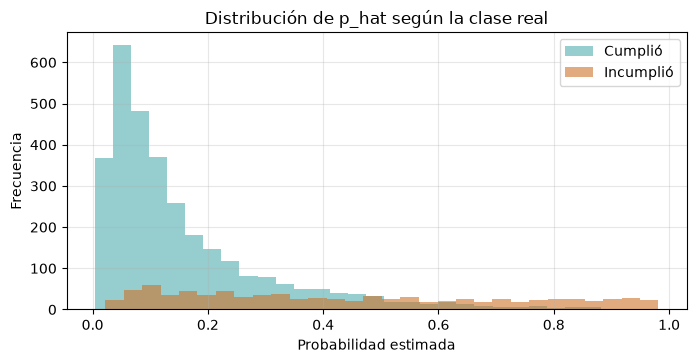

In [6]:
# TODO: (a) calcular p_hat con los coeficientes en unidades originales;
#       (b) recorrer umbrales de 0.1 a 0.9 y armar el DataFrame con la proporción de
#           incumplimientos detectados, la de cumplidores marcados y la exactitud;
#       (c) comparar con la exactitud de predecir siempre la clase mayoritaria;
#       (d) graficar el histograma de p_hat separado por clase real.

p_hat = modelo.predict_proba(X[:, 1:])[:, 1]

umbrales = np.arange(0.1, 0.91, 0.1)
filas = []
for t in umbrales:
    pred = (p_hat >= t).astype(int)
    filas.append({
        "umbral": round(t, 1),
        "incumplimientos_detectados": pred[y == 1].mean(),
        "cumplidores_marcados": pred[y == 0].mean(),
        "exactitud": (pred == y).mean(),
    })
tabla_umbrales = pd.DataFrame(filas)
print(tabla_umbrales)

exactitud_ingenua = (y == 0).mean()
print(f"\nExactitud de predecir 'cumple' para todos: {exactitud_ingenua:.4f}")

fig, ax = plt.subplots()
ax.hist(p_hat[y == 0], bins=30, alpha=0.6, label="Cumplió", color=TURQUESA)
ax.hist(p_hat[y == 1], bins=30, alpha=0.6, label="Incumplió", color=NARANJA)
ax.set_xlabel("Probabilidad estimada")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de p_hat según la clase real")
ax.legend()
plt.show()

### DECIDE

La institución estima que un crédito incobrable cuesta unas **ocho veces** lo que cuesta
rechazar a un cliente que habría cumplido.

1. Con esa relación de costos, ¿qué umbral de la tabla elegirías? Justificarlo con las dos
   columnas de la tabla, no con la exactitud.
2. La exactitud es máxima en un umbral bastante alto. **¿Por qué esa métrica lleva a la
   decisión equivocada** en este problema?
3. ¿Qué información, que no está en los datos, hizo falta para responder la primera
   pregunta?

**Respuesta:**

**Pregunta 1: ¿Qué umbral elegirías con el costo 8:1?**

La institución dice que un incumplimiento no detectado (falso negativo) cuesta 8 veces más que rechazar por error a alguien que iba a cumplir (falso positivo). Esto significa que hay que priorizar detectar incumplimientos, incluso a costa de marcar de más a algunos cumplidores.

Mirá tu tabla: con el umbral 0.1, detectás el 89,1% de los incumplimientos reales, aunque marcás de más al 51,3% de los que iban a cumplir. Con el umbral 0.5 (el "por defecto"), solo detectás el 40% de los incumplimientos.

La forma de pensarlo con números: cada incumplimiento no detectado cuesta 8, cada cumplidor rechazado de más cuesta 1. Entonces conviene bajar el umbral (aceptar más falsos positivos) mientras la ganancia en detección compense esa relación 8:1. Umbrales bajos como 0.1 o 0.2 son los candidatos razonables — te recomendaría comparar concretamente cuánto sube "incumplimientos_detectados" contra cuánto sube "cumplidores_marcados" al pasar de un umbral al siguiente, y elegir el punto donde el beneficio (×8) todavía supera el costo extra.

**Pregunta 2: ¿Por qué la exactitud lleva a la decisión equivocada?**

Mirá dónde está la exactitud máxima en tu tabla: umbral 0.6, con 0.83075. Ahí solo detectás el 31,5% de los incumplimientos reales — es un umbral terrible para el objetivo del negocio.

La razón: la exactitud trata todos los errores como iguales. Como solo el 21,8% de las solicitudes incumplen (viste eso al principio, "Positivos: 873 de 4000"), un modelo que casi siempre dice "cumple" acierta mucho en cantidad total, aunque falle justo en los casos que más importan (los incumplimientos, que son minoría pero mucho más costosos). Es el problema clásico de clases desbalanceadas: la métrica de exactitud no sabe que a la institución le importa 8 veces más un tipo de error que el otro.

**Pregunta 3: ¿Qué información faltaba, que no está en los datos?**

Esa relación de costos (8 veces) — que un incumplimiento cuesta 8 veces lo que un rechazo erróneo — no se puede deducir del dataset. Es información de negocio: cuánto pierde la institución en cada caso, cuál es su tolerancia al riesgo, sus márgenes de ganancia por préstamo, etc. Sin ese dato externo, no hay forma de elegir un umbral "correcto"; el modelo te da probabilidades, pero la decisión depende de algo que no midió ningún atributo del dataset.

---

## Cierre

- **El modelo se ajusta iterando**, porque el sistema $\mathbf{X}^\top(\boldsymbol\sigma-\mathbf{y})=\mathbf{0}$
  no se despeja. El bucle es el mismo del laboratorio anterior con una línea distinta.
- **Los coeficientes se leen en odds.** $e^{\beta_j}$ multiplica odds, no
  probabilidades, y esa distinción cambia la interpretación.
- **Un coeficiente responde qué aporta un atributo dado el resto del modelo**, no cuánto
  importa: el monto quedó subestimado porque la cuota/ingreso ya lo contenía.
- **El modelo produce probabilidades; la decisión exige un umbral**, y ese umbral traduce
  los costos del problema, que no están en los datos.

## Para seguir explorando

Sin obligación y fuera del tiempo de clase:

1. **Separación perfecta.** Agregar al modelo una columna que sea casi una copia de la
   respuesta —por ejemplo `y` con un 2 % de las etiquetas cambiadas— y volver a ajustar.
   Observar la magnitud de los coeficientes. ¿Qué pasa si se aumenta el número de
   iteraciones?
2. **La regularización como remedio.** Repetir lo anterior con `LogisticRegression()` en su
   configuración por omisión y comparar las magnitudes.
3. **Newton en lugar de gradiente.** Implementar un paso de Newton usando la Hessiana
   $\frac1n\mathbf{X}^\top\mathbf{D}\mathbf{X}$ con $\mathbf{D}=\operatorname{diag}\{\hat p_i(1-\hat p_i)\}$
   y contar cuántas iteraciones necesita para alcanzar el mismo costo.